In [22]:
import json
import networkx as nx
import matplotlib.pyplot as plt
from node2vec import Node2Vec
from transformers import pipeline
import spacy



In [23]:
# Load the data
training_data_path = '/Users/monilshah/Documents/02_NWU/10_MSDS_453_NLP/98_project_work/02_wip_data/relations_train_data.json'
test_data_path = '/Users/monilshah/Documents/02_NWU/10_MSDS_453_NLP/98_project_work/02_wip_data/relations_test_data.json'

# Load the test data
with open(test_data_path, 'r') as file:
    test_data = json.load(file)

test_data = test_data[0]

# Load the training data
with open(training_data_path, 'r') as file:
    train_data = json.load(file)

train_data = train_data[0]

# Combine training and test data
all_data = train_data + test_data



In [24]:
# Function to extract triples in the desired format
def extract_triples(data_list):
    extracted_triples = []
    for data in data_list:
        for triple in data.get('triples', []):
            extracted_triples.append({
                "subject": triple['subject'],
                "object": triple['object'],
                "relationship": triple['relation']
            })
    return extracted_triples

# Run the extraction
formatted_triples = extract_triples(all_data)



In [25]:
# Step 1: Create the Knowledge Graph
def create_graph(data):
    G = nx.DiGraph()
    for row in data:
        G.add_edge(row["subject"], row["object"], relationship=row["relationship"])
    return G

# Create the graph
G = create_graph(formatted_triples)



In [26]:
# Step 2: Generate Node Embeddings using node2vec
def generate_node_embeddings(graph):
    node2vec = Node2Vec(graph, dimensions=128, walk_length=10, num_walks=100, workers=4)
    model = node2vec.fit(window=5, min_count=1, workers=4)
    return model

# Generate embeddings for the graph nodes
embedding_model = generate_node_embeddings(G)


Generating walks (CPU: 4): 100%|██████████| 25/25 [00:00<00:00, 167.46it/s]


In [27]:

# Step 3: Process User Input and Extract Entities
def extract_entities_from_text(text):
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(text)
    entities = [ent.text for ent in doc.ents]
    return entities



In [28]:
# Step 4: Query the Graph for Relationships
def query_graph(graph, entities):
    """Retrieve relationships for given entities."""
    relevant_relationships = []
    for entity in entities:
        if graph.has_node(entity):
            edges = list(graph.edges(entity, data=True))
            for e in edges:
                relevant_relationships.append({
                    "subject": e[0],
                    "object": e[1],
                    "relationship": e[2]["relationship"]
                })
    return relevant_relationships




In [29]:

# Step 5: Visualize the Graph with Limited Nodes and Edges
def visualize_graph(graph, entity):
    """Visualize a subgraph of the entity with a limited number of relationships."""
    relationships = query_graph(graph, entity)
    subgraph_nodes = set()
    subgraph_edges = []

    # Add nodes and edges based on the limited relationships
    for rel in relationships:
        subgraph_nodes.add(rel['subject'])
        subgraph_nodes.add(rel['object'])
        subgraph_edges.append((rel['subject'], rel['object']))

    # Create subgraph
    subgraph = graph.subgraph(subgraph_nodes)

    # Draw the subgraph
    pos = nx.spring_layout(subgraph)  # Positioning of nodes
    plt.figure(figsize=(10, 8))
    nx.draw(subgraph, pos, with_labels=True, node_color='skyblue', node_size=3000, font_size=10, font_weight='bold', edge_color='gray')
    edge_labels = nx.get_edge_attributes(subgraph, 'relationship')
    nx.draw_networkx_edge_labels(subgraph, pos, edge_labels=edge_labels)
    plt.title(f"Limited Relationships for {entity}")
    plt.show()



In [55]:

# Step 6: Generate a Descriptive Response Using a Language Model
def generate_response(context):
    """Describe the relationships based on the context"""
    generator = pipeline("text-generation", model="gpt2")  # You can replace this with another model like "gpt-neo" or "GPT-3"
    #generator = pipeline('text2text-generation', model='google/flan-t5-large')
    prompt = f"Describe what all relationships  are talked about in : {context}."
    response = generator(prompt, max_length=500, num_return_sequences=1)
    return response[0]["generated_text"]



In [44]:
# Build context for the language model
def build_context(relationships):
    context_lines = [f"{rel['subject']} and {rel['object']} are connected with {rel['relationship']} ." for rel in relationships]
    return " ".join(context_lines)


In [45]:
user_input = "Apple Inc recently launched new products in the tech market."



In [46]:
entities = extract_entities_from_text(user_input)

# Query the graph based on extracted entities
relevant_relationships = query_graph(G, entities)

context = build_context(relevant_relationships)
print("\nContext for Language Model:")
print(context)



Context for Language Model:
Apple Inc and Steve Jobs are connected with chief_executive_officer . Apple Inc and Apple TV are connected with product_or_material_produced . Apple Inc and software are connected with product_or_material_produced . Apple Inc and iPhone are connected with product_or_material_produced . Apple Inc and Tim Cook are connected with chief_executive_officer . Apple Inc and electronics are connected with industry . Apple Inc and iPad are connected with product_or_material_produced . Apple Inc and iPhone 6S are connected with product_or_material_produced . Apple Inc and iPhone 6S Plus are connected with product_or_material_produced . Apple Inc and information technology are connected with industry . Apple Inc and NASDAQ are connected with stock_exchange . Apple Inc and Apple Pay are connected with product_or_material_produced .


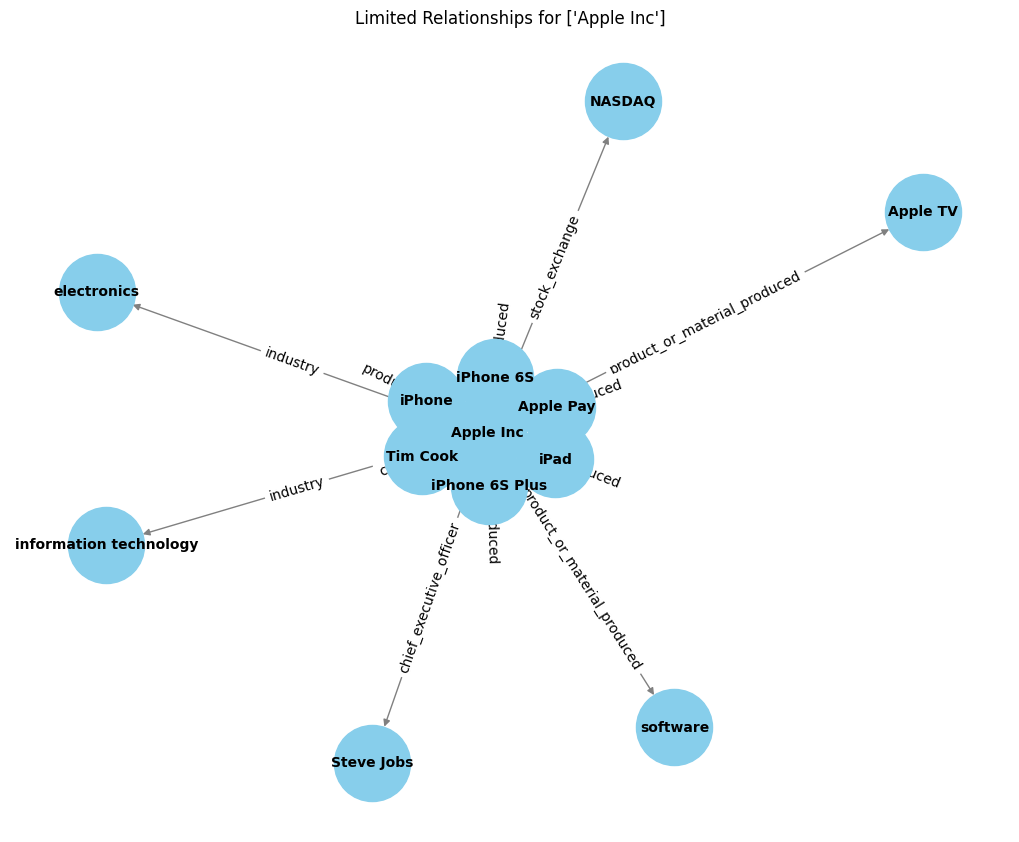

In [47]:

# Visualize the graph and relevant subgraph
visualize_graph(G, entity=entities)



In [56]:
# Generate a response

response = generate_response(context)
print("\nGenerated Response:\n\n")
print(response)


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.



Generated Response:


Describe what all relationships  are talked about in : Apple Inc and Steve Jobs are connected with chief_executive_officer . Apple Inc and Apple TV are connected with product_or_material_produced . Apple Inc and software are connected with product_or_material_produced . Apple Inc and iPhone are connected with product_or_material_produced . Apple Inc and Tim Cook are connected with chief_executive_officer . Apple Inc and electronics are connected with industry . Apple Inc and iPad are connected with product_or_material_produced . Apple Inc and iPhone 6S are connected with product_or_material_produced . Apple Inc and iPhone 6S Plus are connected with product_or_material_produced . Apple Inc and information technology are connected with industry . Apple Inc and NASDAQ are connected with stock_exchange . Apple Inc and Apple Pay are connected with product_or_material_produced .. etc.

What types of products are mentioned? Which are "real" products we see, such as Appl